In [3]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
# from general_utils.utils import decode_matlab_strings, load_img_natraster, TimeSeries, dRSA, get_relevant_output_layers, BrainAreas
from useful_stuff.general_utils.utils import TimeSeries
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.II import dynInformationImbalance
# from general_utils.II import dynInformationImbalance
from useful_stuff.image_processing.computational_models import get_relevant_output_layers


In [67]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0'
    date: str =  '250313'
    img_size = 384
    ks = [1, 10, 50, 100, 200, 500]
    folder_name = 'talia_20each_tizi' # 'fewer_occlusion'
    new_fs = 100
    RDM_metric_signal = 'correlation'
    RDM_metric_model = 'correlation'
    RSA_metric = 'correlation'
    brain_area = "AIT"
    model_name = 'vit_l_16'
    pkg = 'timm'
    img_size = 384
    pooling = 'mean'
    layer_name = 'blocks.1.mlp.fc2'
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)

In [5]:
import h5py
p = "/Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/data/rasters_3-0_250313to21.mat"
with h5py.File(p, "r") as f:
    rasters = f["rasters"][:]      
    


In [48]:
rasters = rasters[:, :300, :].T

In [10]:
print("shape", rasters.shape)
print("min", np.min(rasters))
print("max", np.max(rasters))


shape (14840, 300, 383)
min -9.641416
max 76.58897


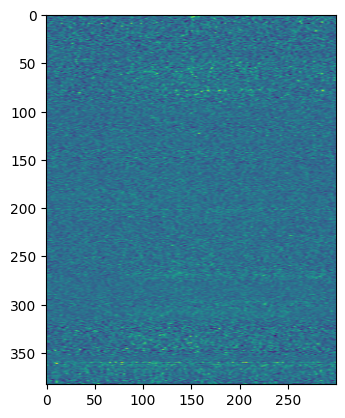

In [11]:
plt.imshow(rasters[0, :, :].T)

In [12]:
from project_specific_utils.dataloader import decode_matlab_strings
allimgs_path = "/Users/tizianocausin/livingstone_lab_local/tiziano/metrics_II/data/allimages_3-0_250313to21.mat"
with h5py.File(allimgs_path, "r") as f:
    try:
        refs = f["allimages"][:]      # shape (N, 1) of object refs
    except KeyError:
        refs = f["uniqueImage"][:]
    # end try:
    monkey_presentation_order = decode_matlab_strings(f, refs)


In [13]:
unique_names = np.unique(monkey_presentation_order)
len(unique_names)
name_to_indices = {
    name: np.where(np.array(monkey_presentation_order) == name)[0].tolist()
    for name in np.unique(monkey_presentation_order)
}

In [73]:
rasters_100Hz = TimeSeries(rasters, 1000)
rasters_100Hz.resample(100)

In [47]:
def compute_split_half_rdm_timeseries(
    rasters,
    name_to_indices,
    n_images=100,
    rdm_metric="cosine_cnt",
    rsa_metric="correlation",
    fs=None,
    random_state=None,
    image_names=None,
    min_trials_per_image=2,
):
    """Compute split-half neural RDM timeseries for a random image subset.

    For each selected image, trial indices are read from ``name_to_indices``.
    Trials are randomly split in two equal halves, averaged within each half,
    and the two image-by-image RDM timeseries are computed with ``dRSA``.
    """
    raster_array = rasters.get_array() if hasattr(rasters, "get_array") else np.asarray(rasters)
    if raster_array.ndim != 3:
        raise ValueError(f"Expected rasters with shape (neurons, time, trials), got {raster_array.shape}.")

    if fs is None:
        fs = rasters.get_fs() if hasattr(rasters, "get_fs") else 1000

    rng = np.random.default_rng(random_state)
    eligible_names = np.array([
        name for name, idx in name_to_indices.items()
        if len(idx) >= min_trials_per_image
    ], dtype=object)
    if len(eligible_names) == 0:
        raise ValueError(f"No images have at least {min_trials_per_image} trials.")

    if image_names is None:
        n_selected = min(n_images, len(eligible_names))
        selected_names = rng.choice(eligible_names, size=n_selected, replace=False).tolist()
    else:
        eligible_set = set(eligible_names)
        selected_names = [name for name in image_names if name in eligible_set]
        if len(selected_names) == 0:
            raise ValueError("None of the requested image_names are present with enough trials.")

    split_a, split_b = [], []
    split_indices = {}
    n_trials_total = raster_array.shape[2]
    for name in selected_names:
        trial_idx = np.asarray(name_to_indices[name], dtype=int)
        if np.any((trial_idx < 0) | (trial_idx >= n_trials_total)):
            raise IndexError(f"Trial indices for {name!r} exceed rasters trial axis length {n_trials_total}.")

        shuffled_idx = rng.permutation(trial_idx)
        half_n = len(shuffled_idx) // 2
        idx_a = np.sort(shuffled_idx[:half_n])
        idx_b = np.sort(shuffled_idx[half_n:half_n * 2])

        split_a.append(raster_array[:, :, idx_a].mean(axis=2))
        split_b.append(raster_array[:, :, idx_b].mean(axis=2))
        split_indices[name] = {"split_a": idx_a.tolist(), "split_b": idx_b.tolist()}

    split_a_rasters = np.stack(split_a, axis=2)
    split_b_rasters = np.stack(split_b, axis=2)
    split_a_ts = TimeSeries(split_a_rasters, fs)
    split_b_ts = TimeSeries(split_b_rasters, fs)

    drsa = dRSA(rdm_metric, rdm_metric, rsa_metric)
    drsa.compute_both_RDM_timeseries(split_a_ts, split_b_ts)
    reliability_matrix = drsa.compute_dRSA()
    same_time_reliability = np.diag(reliability_matrix)

    return {
        "drsa": drsa,
        "selected_names": selected_names,
        "split_indices": split_indices,
        "split_a_rasters": split_a_ts,
        "split_b_rasters": split_b_ts,
        "split_a_RDM_timeseries": drsa.signal_RDM_timeseries,
        "split_b_RDM_timeseries": drsa.model_RDM_timeseries,
        "reliability_matrix": reliability_matrix,
        "same_time_reliability": same_time_reliability,
    }


def compute_split_half_reliability_iterations(
    rasters,
    name_to_indices,
    n_iterations=20,
    n_images=100,
    rdm_metric="cosine_cnt",
    rsa_metric="correlation",
    fs=None,
    random_state=None,
    image_names=None,
    min_trials_per_image=2,
    keep_iteration_results=False,
):
    """Repeat split-half reliability using different trial splits for one image set."""
    if n_iterations < 1:
        raise ValueError("n_iterations must be >= 1.")

    rng = np.random.default_rng(random_state)
    eligible_names = np.array([
        name for name, idx in name_to_indices.items()
        if len(idx) >= min_trials_per_image
    ], dtype=object)
    if len(eligible_names) == 0:
        raise ValueError(f"No images have at least {min_trials_per_image} trials.")

    if image_names is None:
        n_selected = min(n_images, len(eligible_names))
        selected_names = rng.choice(eligible_names, size=n_selected, replace=False).tolist()
    else:
        eligible_set = set(eligible_names)
        selected_names = [name for name in image_names if name in eligible_set]
        if len(selected_names) == 0:
            raise ValueError("None of the requested image_names are present with enough trials.")

    same_time_reliabilities = []
    iteration_results = []
    split_indices = []
    for _ in range(n_iterations):
        result = compute_split_half_rdm_timeseries(
            rasters,
            name_to_indices,
            n_images=len(selected_names),
            rdm_metric=rdm_metric,
            rsa_metric=rsa_metric,
            fs=fs,
            random_state=int(rng.integers(0, np.iinfo(np.uint32).max)),
            image_names=selected_names,
            min_trials_per_image=min_trials_per_image,
        )
        same_time_reliabilities.append(result["same_time_reliability"])
        split_indices.append(result["split_indices"])
        if keep_iteration_results:
            iteration_results.append(result)

    same_time_reliabilities = np.stack(same_time_reliabilities, axis=0)
    output = {
        "selected_names": selected_names,
        "split_indices": split_indices,
        "same_time_reliabilities": same_time_reliabilities,
        "mean_same_time_reliability": same_time_reliabilities.mean(axis=0),
        "std_same_time_reliability": same_time_reliabilities.std(axis=0),
    }
    if keep_iteration_results:
        output["iteration_results"] = iteration_results
    return output


def compute_split_half_reliability_image_sets(
    rasters,
    name_to_indices,
    n_image_sets=10,
    n_iterations=20,
    n_images=100,
    rdm_metric="cosine_cnt",
    rsa_metric="correlation",
    fs=None,
    random_state=None,
    min_trials_per_image=2,
    keep_image_set_results=False,
):
    """Average split-half reliability across different random image sets."""
    if n_image_sets < 1:
        raise ValueError("n_image_sets must be >= 1.")

    rng = np.random.default_rng(random_state)
    image_set_means = []
    selected_names_by_set = []
    image_set_results = []
    for _ in range(n_image_sets):
        result = compute_split_half_reliability_iterations(
            rasters,
            name_to_indices,
            n_iterations=n_iterations,
            n_images=n_images,
            rdm_metric=rdm_metric,
            rsa_metric=rsa_metric,
            fs=fs,
            random_state=int(rng.integers(0, np.iinfo(np.uint32).max)),
            image_names=None,
            min_trials_per_image=min_trials_per_image,
            keep_iteration_results=keep_image_set_results,
        )
        image_set_means.append(result["mean_same_time_reliability"])
        selected_names_by_set.append(result["selected_names"])
        if keep_image_set_results:
            image_set_results.append(result)

    image_set_means = np.stack(image_set_means, axis=0)
    output = {
        "selected_names_by_set": selected_names_by_set,
        "image_set_mean_same_time_reliabilities": image_set_means,
        "mean_same_time_reliability": image_set_means.mean(axis=0),
        "std_same_time_reliability": image_set_means.std(axis=0),
    }
    if keep_image_set_results:
        output["image_set_results"] = image_set_results
    return output


# Examples:
# same_images = compute_split_half_reliability_iterations(
#     rasters, name_to_indices, n_iterations=20, n_images=100,
#     rdm_metric=cfg.RDM_metric_signal, rsa_metric=cfg.RSA_metric,
#     fs=1000, random_state=0,
# )
# plt.plot(same_images["mean_same_time_reliability"])
#
# image_sets = compute_split_half_reliability_image_sets(
#     rasters, name_to_indices, n_image_sets=10, n_iterations=20, n_images=100,
#     rdm_metric=cfg.RDM_metric_signal, rsa_metric=cfg.RSA_metric,
#     fs=1000, random_state=0,
# )
# plt.plot(image_sets["mean_same_time_reliability"])



In [60]:
def compute_split_half_dynII_timeseries(
    rasters,
    name_to_indices,
    n_images=100,
    rdm_metric="cosine_cnt",
    k=1,
    rsa_metric="correlation",
    fs=None,
    random_state=None,
    image_names=None,
    min_trials_per_image=2,
):
    """Compute split-half dynII timeseries for a random image subset."""
    raster_array = rasters.get_array() if hasattr(rasters, "get_array") else np.asarray(rasters)
    if raster_array.ndim != 3:
        raise ValueError(f"Expected rasters with shape (neurons, time, trials), got {raster_array.shape}.")

    if fs is None:
        fs = rasters.get_fs() if hasattr(rasters, "get_fs") else 1000

    rng = np.random.default_rng(random_state)
    eligible_names = np.array([
        name for name, idx in name_to_indices.items()
        if len(idx) >= min_trials_per_image
    ], dtype=object)
    if len(eligible_names) == 0:
        raise ValueError(f"No images have at least {min_trials_per_image} trials.")

    if image_names is None:
        n_selected = min(n_images, len(eligible_names))
        selected_names = rng.choice(eligible_names, size=n_selected, replace=False).tolist()
    else:
        eligible_set = set(eligible_names)
        selected_names = [name for name in image_names if name in eligible_set]
        if len(selected_names) == 0:
            raise ValueError("None of the requested image_names are present with enough trials.")

    split_a, split_b = [], []
    split_indices = {}
    n_trials_total = raster_array.shape[2]
    for name in selected_names:
        trial_idx = np.asarray(name_to_indices[name], dtype=int)
        if np.any((trial_idx < 0) | (trial_idx >= n_trials_total)):
            raise IndexError(f"Trial indices for {name!r} exceed rasters trial axis length {n_trials_total}.")

        shuffled_idx = rng.permutation(trial_idx)
        half_n = len(shuffled_idx) // 2
        idx_a = np.sort(shuffled_idx[:half_n])
        idx_b = np.sort(shuffled_idx[half_n:half_n * 2])

        split_a.append(raster_array[:, :, idx_a].mean(axis=2))
        split_b.append(raster_array[:, :, idx_b].mean(axis=2))
        split_indices[name] = {"split_a": idx_a.tolist(), "split_b": idx_b.tolist()}

    split_a_rasters = np.stack(split_a, axis=2)
    split_b_rasters = np.stack(split_b, axis=2)
    split_a_ts = TimeSeries(split_a_rasters, fs)
    split_b_ts = TimeSeries(split_b_rasters, fs)

    dynii = dynInformationImbalance(rdm_metric, rdm_metric, k=k, RSA_metric=rsa_metric)
    dynii.compute_both_RDM_timeseries(split_a_ts, split_b_ts)
    dynii.compute_both_distance_ranks_timeseries()
    dynII_A2B, dynII_B2A = dynii.compute_both_dynII()
    same_time_A2B = np.diag(dynII_A2B)
    same_time_B2A = np.diag(dynII_B2A)
    same_time_reliability = (same_time_A2B + same_time_B2A) / 2

    return {
        "dynii": dynii,
        "selected_names": selected_names,
        "split_indices": split_indices,
        "split_a_rasters": split_a_ts,
        "split_b_rasters": split_b_ts,
        "split_a_RDM_timeseries": dynii.signal_RDM_timeseries,
        "split_b_RDM_timeseries": dynii.model_RDM_timeseries,
        "dynII_A2B": dynII_A2B,
        "dynII_B2A": dynII_B2A,
        "same_time_A2B": same_time_A2B,
        "same_time_B2A": same_time_B2A,
        "same_time_reliability": same_time_reliability,
    }


def compute_split_half_dynII_reliability_iterations(
    rasters,
    name_to_indices,
    n_iterations=20,
    n_images=100,
    rdm_metric="cosine_cnt",
    k=1,
    rsa_metric="correlation",
    fs=None,
    random_state=None,
    image_names=None,
    min_trials_per_image=2,
    keep_iteration_results=False,
):
    """Repeat split-half dynII using different trial splits for one image set."""
    if n_iterations < 1:
        raise ValueError("n_iterations must be >= 1.")

    rng = np.random.default_rng(random_state)
    eligible_names = np.array([
        name for name, idx in name_to_indices.items()
        if len(idx) >= min_trials_per_image
    ], dtype=object)
    if len(eligible_names) == 0:
        raise ValueError(f"No images have at least {min_trials_per_image} trials.")

    if image_names is None:
        n_selected = min(n_images, len(eligible_names))
        selected_names = rng.choice(eligible_names, size=n_selected, replace=False).tolist()
    else:
        eligible_set = set(eligible_names)
        selected_names = [name for name in image_names if name in eligible_set]
        if len(selected_names) == 0:
            raise ValueError("None of the requested image_names are present with enough trials.")

    same_time_A2B = []
    same_time_B2A = []
    same_time_reliabilities = []
    iteration_results = []
    split_indices = []
    for _ in range(n_iterations):
        result = compute_split_half_dynII_timeseries(
            rasters,
            name_to_indices,
            n_images=len(selected_names),
            rdm_metric=rdm_metric,
            k=k,
            rsa_metric=rsa_metric,
            fs=fs,
            random_state=int(rng.integers(0, np.iinfo(np.uint32).max)),
            image_names=selected_names,
            min_trials_per_image=min_trials_per_image,
        )
        same_time_A2B.append(result["same_time_A2B"])
        same_time_B2A.append(result["same_time_B2A"])
        same_time_reliabilities.append(result["same_time_reliability"])
        split_indices.append(result["split_indices"])
        if keep_iteration_results:
            iteration_results.append(result)

    same_time_A2B = np.stack(same_time_A2B, axis=0)
    same_time_B2A = np.stack(same_time_B2A, axis=0)
    same_time_reliabilities = np.stack(same_time_reliabilities, axis=0)
    output = {
        "selected_names": selected_names,
        "split_indices": split_indices,
        "same_time_A2B": same_time_A2B,
        "same_time_B2A": same_time_B2A,
        "same_time_reliabilities": same_time_reliabilities,
        "mean_same_time_A2B": same_time_A2B.mean(axis=0),
        "mean_same_time_B2A": same_time_B2A.mean(axis=0),
        "mean_same_time_reliability": same_time_reliabilities.mean(axis=0),
        "std_same_time_A2B": same_time_A2B.std(axis=0),
        "std_same_time_B2A": same_time_B2A.std(axis=0),
        "std_same_time_reliability": same_time_reliabilities.std(axis=0),
    }
    if keep_iteration_results:
        output["iteration_results"] = iteration_results
    return output


def compute_split_half_dynII_reliability_image_sets(
    rasters,
    name_to_indices,
    n_image_sets=10,
    n_iterations=20,
    n_images=100,
    rdm_metric="cosine_cnt",
    k=1,
    rsa_metric="correlation",
    fs=None,
    random_state=None,
    min_trials_per_image=2,
    keep_image_set_results=False,
):
    """Average split-half dynII reliability across random image sets."""
    if n_image_sets < 1:
        raise ValueError("n_image_sets must be >= 1.")

    rng = np.random.default_rng(random_state)
    image_set_A2B = []
    image_set_B2A = []
    image_set_reliabilities = []
    selected_names_by_set = []
    image_set_results = []
    for _ in range(n_image_sets):
        result = compute_split_half_dynII_reliability_iterations(
            rasters,
            name_to_indices,
            n_iterations=n_iterations,
            n_images=n_images,
            rdm_metric=rdm_metric,
            k=k,
            rsa_metric=rsa_metric,
            fs=fs,
            random_state=int(rng.integers(0, np.iinfo(np.uint32).max)),
            image_names=None,
            min_trials_per_image=min_trials_per_image,
            keep_iteration_results=keep_image_set_results,
        )
        image_set_A2B.append(result["mean_same_time_A2B"])
        image_set_B2A.append(result["mean_same_time_B2A"])
        image_set_reliabilities.append(result["mean_same_time_reliability"])
        selected_names_by_set.append(result["selected_names"])
        if keep_image_set_results:
            image_set_results.append(result)

    image_set_A2B = np.stack(image_set_A2B, axis=0)
    image_set_B2A = np.stack(image_set_B2A, axis=0)
    image_set_reliabilities = np.stack(image_set_reliabilities, axis=0)
    output = {
        "selected_names_by_set": selected_names_by_set,
        "image_set_mean_same_time_A2B": image_set_A2B,
        "image_set_mean_same_time_B2A": image_set_B2A,
        "image_set_mean_same_time_reliabilities": image_set_reliabilities,
        "mean_same_time_A2B": image_set_A2B.mean(axis=0),
        "mean_same_time_B2A": image_set_B2A.mean(axis=0),
        "mean_same_time_reliability": image_set_reliabilities.mean(axis=0),
        "std_same_time_A2B": image_set_A2B.std(axis=0),
        "std_same_time_B2A": image_set_B2A.std(axis=0),
        "std_same_time_reliability": image_set_reliabilities.std(axis=0),
    }
    if keep_image_set_results:
        output["image_set_results"] = image_set_results
    return output


# Example:
# dynii_sets = compute_split_half_dynII_reliability_image_sets(
#     rasters, name_to_indices, n_image_sets=10, n_iterations=20, n_images=100,
#     rdm_metric=cfg.RDM_metric_signal, k=10, rsa_metric=cfg.RSA_metric,
#     fs=1000, random_state=0,
# )
# plt.plot(dynii_sets["mean_same_time_A2B"], label="A2B")
# plt.plot(dynii_sets["mean_same_time_B2A"], label="B2A")
# plt.plot(dynii_sets["mean_same_time_reliability"], label="mean")
# plt.legend()



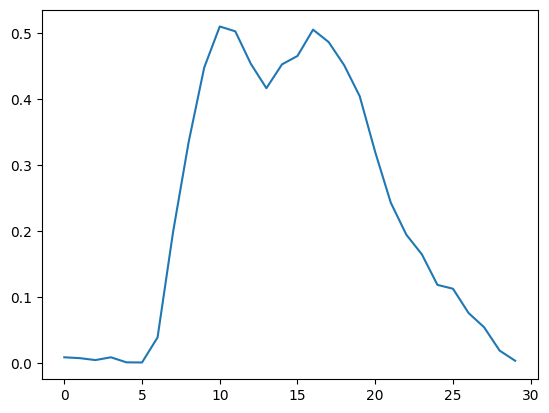

In [75]:
same_images = compute_split_half_reliability_iterations(
    rasters_100Hz, name_to_indices, n_iterations=20, n_images=100,
    rdm_metric=cfg.RDM_metric_signal, rsa_metric=cfg.RSA_metric,
    fs=1000, random_state=0,
)
plt.plot(same_images["mean_same_time_reliability"])


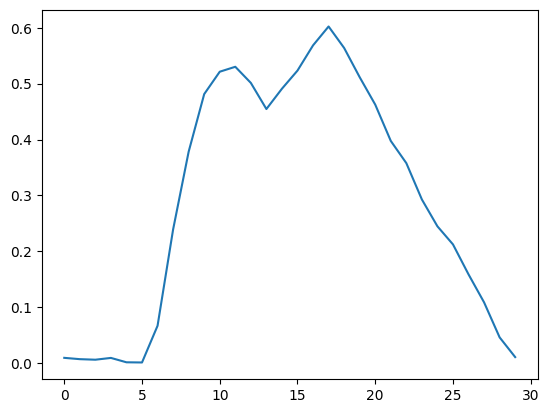

In [76]:
same_images = compute_split_half_reliability_iterations(
    rasters_100Hz, name_to_indices, n_iterations=20, n_images=100,
    rdm_metric="cosine", rsa_metric=cfg.RSA_metric,
    fs=1000, random_state=0,
)
plt.plot(same_images["mean_same_time_reliability"])

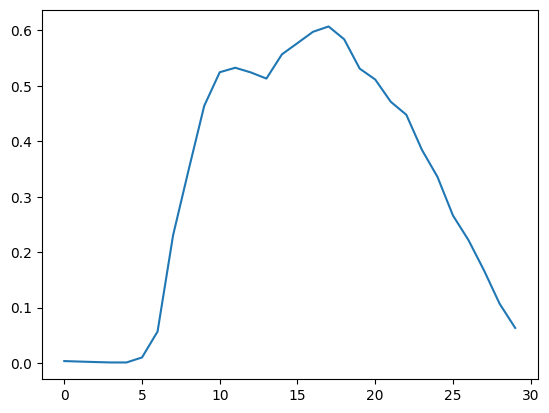

In [82]:
image_sets = compute_split_half_reliability_image_sets(
    rasters_100Hz, name_to_indices, n_image_sets=10, n_iterations=5, n_images=100,
    rdm_metric="cosine", rsa_metric=cfg.RSA_metric,
    fs=1000, random_state=0,
)
plt.plot(image_sets["mean_same_time_reliability"])



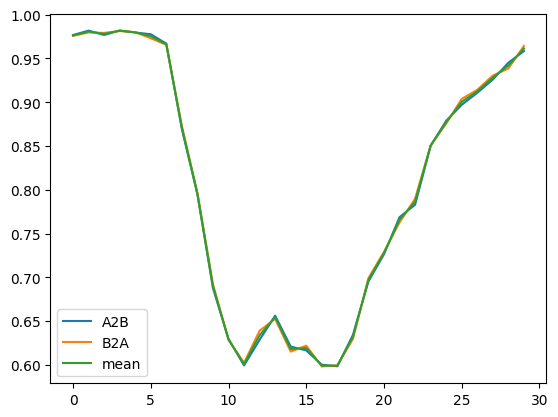

In [79]:
from useful_stuff.general_utils.II import dynInformationImbalance
dynii_sets = compute_split_half_dynII_reliability_image_sets(
    rasters_100Hz, name_to_indices, n_image_sets=10, n_iterations=2, n_images=100,
    rdm_metric="correlation", k=10, rsa_metric=cfg.RSA_metric,
    fs=1000, random_state=0,
)
plt.plot(dynii_sets["mean_same_time_A2B"], label="A2B")
plt.plot(dynii_sets["mean_same_time_B2A"], label="B2A")
plt.plot(dynii_sets["mean_same_time_reliability"], label="mean")
plt.legend()

In [24]:
tot_entries = 0
min_pres = 100
max_pres = 0
for k, v in name_to_indices.items():
    tot_entries += len(v)
    min_pres = len(v) if len(v) < min_pres else min_pres
    max_pres = len(v) if len(v) > max_pres else max_pres

print("mean", tot_entries/(len(name_to_indices.keys())))
print("min:", min_pres, "max:", max_pres)

mean 19.123711340206185
min: 16 max: 23


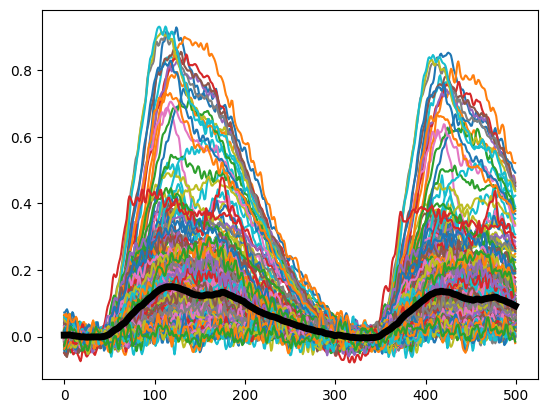

In [25]:
avg_timecourse_neu = np.mean(rasters, axis=(0))
avg_timecourse = np.mean(rasters, axis=(0,2))
plt.plot(avg_timecourse_neu)
plt.plot(avg_timecourse, color="k", linewidth=5)

In [29]:
from project_specific_utils.dataloader import load_img_natraster
neu = load_img_natraster(paths, "three0", "250313")

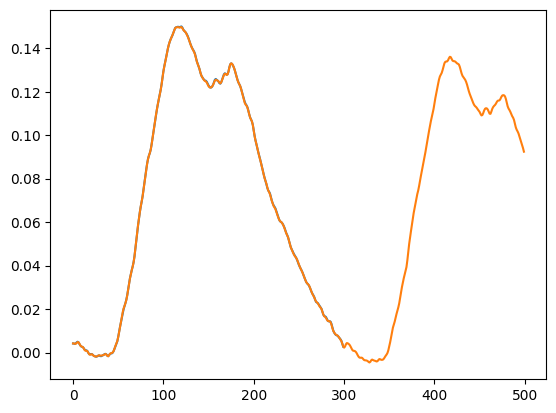

In [34]:
plt.plot(neu.array.mean(axis=(0,2)).T)
plt.plot(avg_timecourse)

failed to load /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_correlation-correlation_three0_250313_AIT_vit_l_16_384_blocks.0.mlp.fc2_100Hz.npz
failed to load /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_correlation-correlation_three0_250313_AIT_vit_l_16_384_blocks.1.mlp.fc2_100Hz.npz
failed to load /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_correlation-correlation_three0_250313_AIT_vit_l_16_384_blocks.2.mlp.fc2_100Hz.npz
failed to load /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_correlation-correlation_three0_250313_AIT_vit_l_16_384_blocks.3.mlp.fc2_100Hz.npz
failed to load /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_correlation-correlation_three0_250313_AIT_vit_l_16_384_blocks.4.mlp.fc2_100Hz.npz
failed to load /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_correlation-correlation_three0_250313_AIT_vit_l_16_384_blocks.5.mlp.

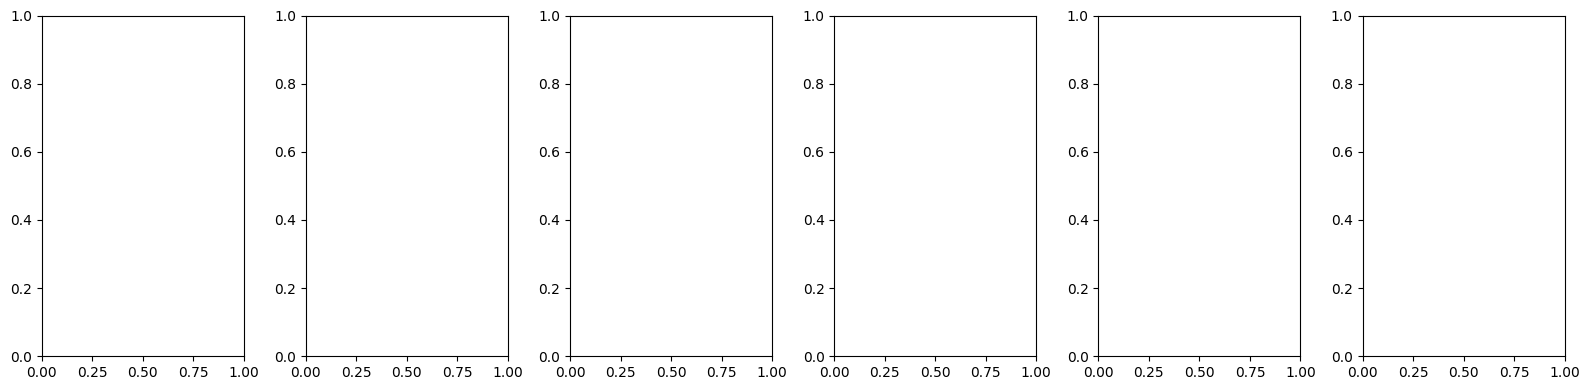

In [69]:
from useful_stuff.general_utils.plots import truncate_colormap
base_cmap = plt.cm.turbo

cmap = truncate_colormap(base_cmap, 0.10, 0.90)
fig, ax = plt.subplots(1,len(cfg.ks), figsize=(16, 4))
for idx_k, k in enumerate(cfg.ks):
    for i_col, l in enumerate(layers):
        color = cmap(i_col / (len(layers) - 1))
        try:
            A2B_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            B2A_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            A2B = np.load(A2B_fn)["arr_0"]
            B2A = np.load(B2A_fn)["arr_0"]
            if k == cfg.ks[-1]:
                ax[idx_k].plot(A2B, color=color, linewidth=2, label=l, linestyle="--")
                ax[idx_k].plot(B2A, color=color, label=l, linewidth=2)
            else:
                ax[idx_k].plot(A2B, color=color, linewidth=2, linestyle="--")
                ax[idx_k].plot(B2A, color=color, linewidth=2)
            
            ax[idx_k].set_title(f"k = {k}")
            # ax[idx_k].set_ylim([1, .6])
        except FileNotFoundError:
            print(f"failed to load {A2B_fn}")
            pass
    
# fig.legend(
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5),
#     frameon=False
# );
plt.tight_layout()

In [41]:
RSA_fn = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
np.max(np.load(RSA_fn)["arr_0"])

0.11503080478728135

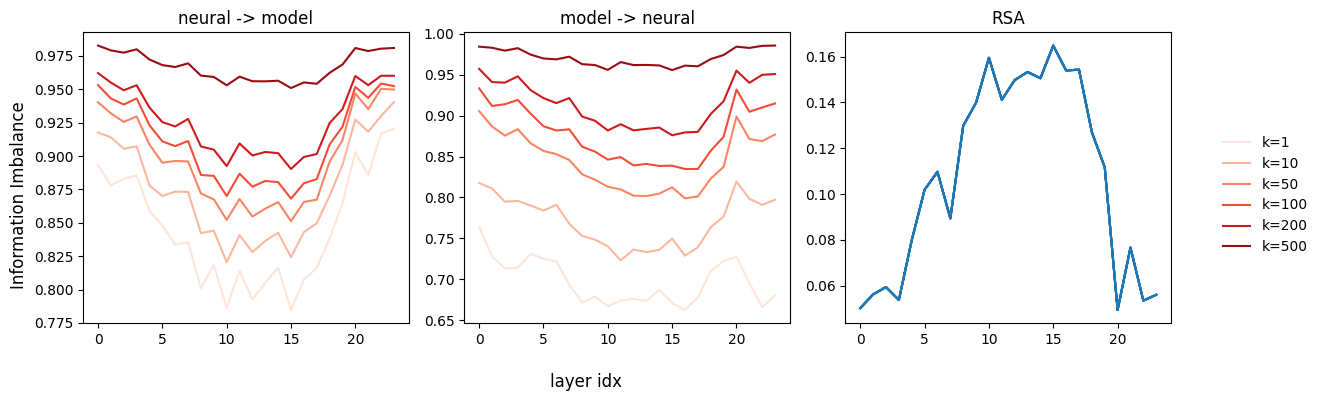

In [61]:
from general_utils.plots import truncate_colormap
base_cmap = plt.cm.Reds

cmap = truncate_colormap(base_cmap, 0.10, 0.90)
fig, ax = plt.subplots(1,3, figsize=(12, 4))
for idx_k, k in enumerate(cfg.ks):
    A2B_tot = []
    B2A_tot = []
    RSA_tot = []
    color = cmap(idx_k / (len(cfg.ks) - 1))
    for l in layers:
        A2B_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        B2A_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        RSA_fn = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        A2B = np.min(np.load(A2B_fn)["arr_0"])
        B2A = np.min(np.load(B2A_fn)["arr_0"])
        RSA = np.max(np.load(RSA_fn)["arr_0"])
        A2B_tot.append(A2B)
        B2A_tot.append(B2A)
        RSA_tot.append(RSA)
    ax[0].plot(A2B_tot, color=color, label=f"k={k}")
    ax[1].plot(B2A_tot, color=color,)
    ax[2].plot(RSA_tot, color="tab:blue",)
fig.supylabel("Information Imbalance")
fig.supxlabel("layer idx")
ax[0].set_title("neural -> model")
ax[1].set_title("model -> neural")
ax[2].set_title("RSA")

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
);
plt.tight_layout()

In [59]:
np.corrcoef(A2B_tot, RSA_tot)

array([[ 1.        , -0.81077005],
       [-0.81077005,  1.        ]])